<a href="https://colab.research.google.com/github/verma-lokesh/Lokesh_68_CA1/blob/main/hospital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Hospital Readmission Prediction
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhaypanchal/hospital-readmission-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 378k/378k [00:00<00:00, 23.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/abhaypanchal/hospital-readmission-prediction-dataset/versions/1


In [ ]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
# See what files were downloaded
print(os.listdir(path))

['hospital_readmission.csv']


In [ ]:
df=pd.read_csv(os.path.join(path,"hospital_readmission.csv"))

In [ ]:
df.head()

,age,length_of_stay_days,num_diagnoses,num_medications,prev_admissions,glucose_level,bmi,has_diabetes,discharge_type,readmitted_30days
0,22.0,28.0,2.0,13.0,4.0,89.1,48.4,1.0,2.0,0
1,44.0,12.0,7.0,11.0,2.0,254.8,23.9,1.0,0.0,1
2,34.0,15.0,9.0,16.0,6.0,270.2,16.7,0.0,1.0,1
3,39.0,15.0,5.0,16.0,6.0,208.6,18.2,0.0,1.0,1
4,62.0,24.0,1.0,6.0,6.0,233.1,44.0,0.0,0.0,1


In [ ]:
print(df.shape)
print(df.info())

(32300, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32300 entries, 0 to 32299
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  31653 non-null  object 
 1   length_of_stay_days  31652 non-null  float64
 2   num_diagnoses        31655 non-null  float64
 3   num_medications      31654 non-null  float64
 4   prev_admissions      31654 non-null  float64
 5   glucose_level        31654 non-null  float64
 6   bmi                  31654 non-null  float64
 7   has_diabetes         31653 non-null  float64
 8   discharge_type       31655 non-null  float64
 9   readmitted_30days    32300 non-null  int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 2.5+ MB
None


In [ ]:
print(df.isnull().sum())

age                    647
length_of_stay_days    648
num_diagnoses          645
num_medications        646
prev_admissions        646
glucose_level          646
bmi                    646
has_diabetes           647
discharge_type         645
readmitted_30days        0
dtype: int64


In [ ]:
print(df.columns.tolist())

['age', 'length_of_stay_days', 'num_diagnoses', 'num_medications', 'prev_admissions', 'glucose_level', 'bmi', 'has_diabetes', 'discharge_type', 'readmitted_30days']


In [ ]:
X = df.drop("readmitted_30days", axis=1)
y = df["readmitted_30days"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
numeric_cols = [
    "age",
    "length_of_stay_days",
    "num_diagnoses",
    "num_medications",
    "prev_admissions",
    "glucose_level",
    "bmi"
]

In [ ]:
numeric_cols = [
    "age",
    "length_of_stay_days",
    "num_diagnoses",
    "num_medications",
    "prev_admissions",
    "glucose_level",
    "bmi"
]

for col in numeric_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

In [ ]:
for col in numeric_cols:
    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

In [ ]:
print(X_train[numeric_cols].isnull().sum())
print(X_test[numeric_cols].isnull().sum())

age                    0
length_of_stay_days    0
num_diagnoses          0
num_medications        0
prev_admissions        0
glucose_level          0
bmi                    0
dtype: int64
age                    0
length_of_stay_days    0
num_diagnoses          0
num_medications        0
prev_admissions        0
glucose_level          0
bmi                    0
dtype: int64


In [ ]:
categorical_cols = [
    "has_diabetes",
    "discharge_type"
]

for col in categorical_cols:
    mode_value = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty="l2",
    max_iter=1000,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8755678193284012


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2573  659]
 [ 686 2542]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.80      0.79      3232
           1       0.79      0.79      0.79      3228

    accuracy                           0.79      6460
   macro avg       0.79      0.79      0.79      6460
weighted avg       0.79      0.79      0.79      6460



In [ ]:
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives :", TP)

True Negatives : 2573
False Positives: 659
False Negatives: 686
True Positives : 2542


In [ ]:
feature_names = X.columns

coefficients = pd.Series(
    model.coef_[0],
    index=feature_names
)

print(coefficients.sort_values(ascending=False))

prev_admissions        1.469608
length_of_stay_days    0.726001
age                    0.687066
num_medications        0.555433
num_diagnoses          0.554685
has_diabetes           0.398683
bmi                    0.345238
glucose_level          0.337796
discharge_type        -0.534060
dtype: float64


In [ ]:
print(coefficients.sort_values())

discharge_type        -0.534060
glucose_level          0.337796
bmi                    0.345238
has_diabetes           0.398683
num_diagnoses          0.554685
num_medications        0.555433
age                    0.687066
length_of_stay_days    0.726001
prev_admissions        1.469608
dtype: float64


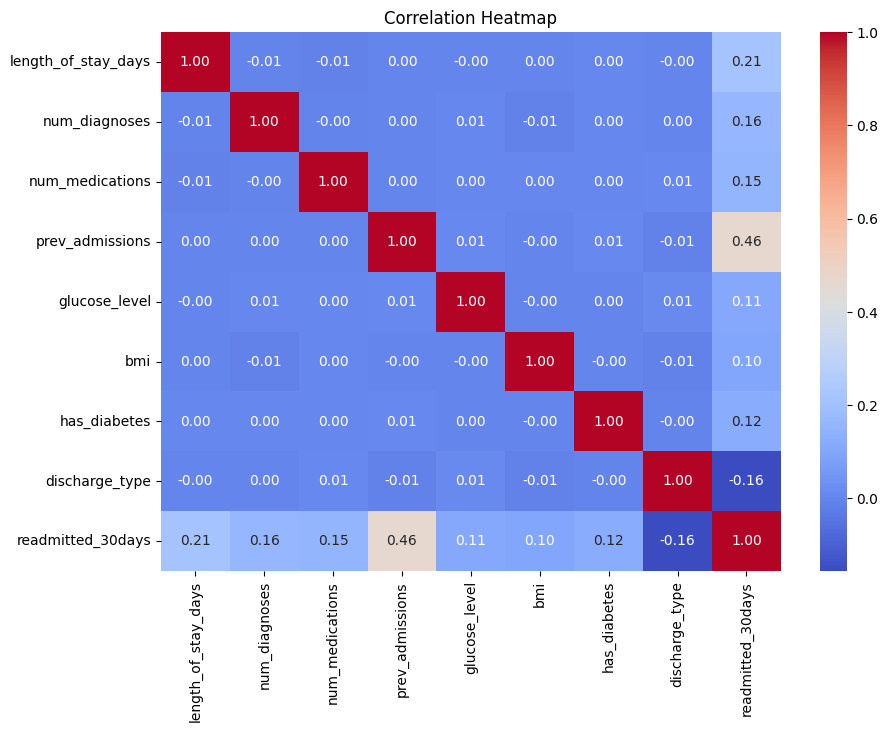

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

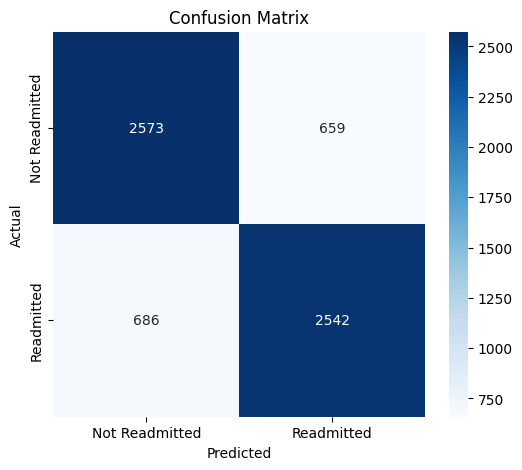

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Readmitted", "Readmitted"],
    yticklabels=["Not Readmitted", "Readmitted"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()